# Prediksi Penggunaan AI Tools

Notebook ini memprediksi penggunaan AI secara umum (`AISelect`) dan adopsi AI Agent (`AIAgents`) dengan Logistic Regression, Random Forest, dan CatBoost. Alur mencakup pembersihan data, split 80:20, penanganan imbalance pada data training, evaluasi F1-score, confusion matrix, serta feature importance CatBoost.

## 1. Setup lingkungan

Jalankan sel instalasi berikut terlebih dahulu di Google Colab.

In [4]:
!pip install catboost imbalanced-learn

In [5]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

## 2. Membaca dataset

Secara default notebook mencari `results.csv` di `MyDrive/project-ml/dataset`. Ubah `PROJECT_DIR` apabila folder Anda berbeda. Agar RAM Colab tetap aman, hanya 12 kolom yang diperlukan yang dibaca dari CSV.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/PROJECT ML')  # Sesuaikan bila perlu
candidate_dirs = [PROJECT_DIR / 'dataset', Path('/content/dataset'), Path('/content')]
DATA_DIR = next((path for path in candidate_dirs if (path / 'results.csv').exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        'results.csv tidak ditemukan. Letakkan file di '
        f'{PROJECT_DIR / "dataset"}, /content/dataset, atau /content.'
    )

data_path = DATA_DIR / 'results.csv'
LOAD_COLUMNS = [
    'Age', 'YearsCode', 'WorkExp', 'CompTotal', 'DevType',
    'OpSysProfessional use', 'DevEnvsHaveWorkedWith',
    'LanguageHaveWorkedWith', 'WebframeHaveWorkedWith',
    'DatabaseHaveWorkedWith', 'AISelect', 'AIAgents',
]
df_raw = pd.read_csv(
    data_path, usecols=LOAD_COLUMNS, low_memory=False, encoding='utf-8-sig'
)
print(f'Dataset: {data_path}')
memory_mb = df_raw.memory_usage(deep=True).sum() / 1024**2
print(f'Ukuran  : {df_raw.shape[0]:,} baris x {df_raw.shape[1]:,} kolom')
print(f'Memori dataframe: {memory_mb:.1f} MB')
display(df_raw.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/Colab Notebooks/PROJECT ML/dataset/results.csv
Ukuran  : 49,191 baris x 12 kolom
Memori dataframe: 27.5 MB


,Age,WorkExp,YearsCode,DevType,CompTotal,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,WebframeHaveWorkedWith,DevEnvsHaveWorkedWith,OpSysProfessional use,AISelect,AIAgents
0,25-34 years old,8.0,14.0,"Developer, mobile",52800.0,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,NaN,Android Studio;Notepad++;Visual Studio;Visual ...,Windows;MacOS;Android;iOS;iPadOS,"Yes, I use AI tools monthly or infrequently","Yes, I use AI agents at work monthly or infreq..."
1,25-34 years old,2.0,10.0,"Developer, back-end",90000.0,Java,Dynamodb;MongoDB,Spring Boot,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,MacOS,"Yes, I use AI tools weekly","No, and I don't plan to"
2,35-44 years old,10.0,12.0,"Developer, front-end",2214000.0,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Next.js;Node.js;React,Visual Studio Code,MacOS,"Yes, I use AI tools daily","Yes, I use AI agents at work weekly"


## 3. Definisi fitur dan target

Nama fitur ringkas pada panduan dipetakan ke nama kolom aktual survei. Nilai target yang diawali `Yes` menjadi 1 dan nilai yang diawali `No` menjadi 0. `Age` dikonversi dari rentang umur ke titik tengah, sedangkan jawaban khusus pada `YearsCode` dikonversi ke nilai numerik yang masuk akal.

In [7]:
NUMERIC_FEATURES = ['Age', 'YearsCode', 'WorkExp', 'CompTotal']
CATEGORICAL_FEATURES = ['DevType', 'OpSys', 'DevEnvs', 'Language', 'Webframe', 'Database']
COLUMN_MAP = {
    'DevType': 'DevType',
    'OpSys': 'OpSysProfessional use',
    'DevEnvs': 'DevEnvsHaveWorkedWith',
    'Language': 'LanguageHaveWorkedWith',
    'Webframe': 'WebframeHaveWorkedWith',
    'Database': 'DatabaseHaveWorkedWith',
}
TARGETS = ['AISelect', 'AIAgents']

required_columns = NUMERIC_FEATURES + list(COLUMN_MAP.values()) + TARGETS
missing_columns = [column for column in required_columns if column not in df_raw.columns]
if missing_columns:
    raise KeyError(f'Kolom wajib tidak ditemukan: {missing_columns}')

def age_to_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    if 'Under 18' in text:
        return 17
    if '65 years or older' in text:
        return 70
    numbers = pd.Series([text]).str.extractall(r'(\d+)')[0].astype(float).tolist()
    return np.mean(numbers) if numbers else np.nan

def years_code_to_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    if 'Less than 1 year' in text:
        return 0.5
    if 'More than 50 years' in text:
        return 51.0
    return pd.to_numeric(value, errors='coerce')

def target_to_binary(series):
    result = pd.Series(np.nan, index=series.index, dtype='float64')
    result.loc[series.astype('string').str.startswith('Yes', na=False)] = 1
    result.loc[series.astype('string').str.startswith('No', na=False)] = 0
    return result

X = df_raw[NUMERIC_FEATURES].copy()
for alias, source in COLUMN_MAP.items():
    X[alias] = df_raw[source]

X['Age'] = X['Age'].map(age_to_number)
X['YearsCode'] = X['YearsCode'].map(years_code_to_number)
X['WorkExp'] = pd.to_numeric(X['WorkExp'], errors='coerce')
X['CompTotal'] = pd.to_numeric(X['CompTotal'], errors='coerce')
Y_1 = target_to_binary(df_raw['AISelect'])
Y_2 = target_to_binary(df_raw['AIAgents'])

print('Distribusi target AISelect:')
display(Y_1.value_counts(dropna=False).rename(index={0.0: 'Tidak', 1.0: 'Ya', np.nan: 'Kosong'}))
print('Distribusi target AIAgents:')
display(Y_2.value_counts(dropna=False).rename(index={0.0: 'Tidak', 1.0: 'Ya', np.nan: 'Kosong'}))
display(X.head())

# Data mentah tidak diperlukan lagi; melepaskannya menghemat RAM sebelum training.
del df_raw

Distribusi target AISelect:


,count
Ya,26469
NaN,15471
Tidak,7251


Distribusi target AIAgents:


,count
Tidak,22044
NaN,17272
Ya,9875


,Age,YearsCode,WorkExp,CompTotal,DevType,OpSys,DevEnvs,Language,Webframe,Database
0,29.5,14.0,8.0,52800.0,"Developer, mobile",Windows;MacOS;Android;iOS;iPadOS,Android Studio;Notepad++;Visual Studio;Visual ...,Bash/Shell (all shells);Dart;SQL,NaN,Cloud Firestore;PostgreSQL
1,29.5,10.0,2.0,90000.0,"Developer, back-end",MacOS,IntelliJ IDEA;PyCharm;Visual Studio Code;Xcode,Java,Spring Boot,Dynamodb;MongoDB
2,39.5,12.0,10.0,2214000.0,"Developer, front-end",MacOS,Visual Studio Code,Dart;HTML/CSS;JavaScript;TypeScript,Next.js;Node.js;React,MongoDB;MySQL;PostgreSQL
3,39.5,5.0,4.0,31200.0,"Developer, back-end",Windows;Ubuntu,NaN,Java;Kotlin;SQL,Spring Boot,NaN
4,39.5,22.0,21.0,60000.0,Engineering manager,Windows;Ubuntu;Debian,Eclipse;IntelliJ IDEA;Jupyter Notebook/Jupyter...,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...


## 4. Fungsi pemodelan modular

Karena data berisi fitur campuran, notebook menggunakan `SMOTENC`, yaitu varian SMOTE yang menjaga fitur kategorikal tetap berupa kategori. Jawaban multi-pilihan dipadatkan menjadi teknologi paling umum yang digunakan responden (maksimal 25 kategori per fitur, ditentukan hanya dari training set), sehingga kombinasi unik tidak menghabiskan RAM. Nilai numerik tak hingga dan outlier dibersihkan berdasarkan data training; `CompTotal` juga ditransformasi dengan `log1p` agar nilai mata uang ekstrem tidak overflow.

In [8]:
def train_and_evaluate(X, y, scenario_name):
    valid_target = y.notna()
    X_scenario = X.loc[valid_target].copy()
    y_scenario = y.loc[valid_target].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario,
        y_scenario,
        test_size=0.20,
        stratify=y_scenario,
        random_state=RANDOM_STATE,
    )

    # Padatkan jawaban seperti 'Python;SQL;JavaScript' menjadi satu kategori umum.
    # Daftar kategori dipelajari dari training set agar tidak terjadi leakage.
    X_train_compact = X_train.copy()
    X_test_compact = X_test.copy()
    for column in CATEGORICAL_FEATURES:
        tokens = (
            X_train[column].dropna().astype(str).str.split(';').explode().str.strip()
        )
        common_categories = tokens[tokens.ne('')].value_counts().head(25).index.tolist()
        category_rank = {value: rank for rank, value in enumerate(common_categories)}

        def select_category(value):
            if pd.isna(value):
                return 'Tidak diketahui'
            choices = [item.strip() for item in str(value).split(';')]
            known = [item for item in choices if item in category_rank]
            return min(known, key=category_rank.get) if known else 'Lainnya'

        X_train_compact[column] = X_train[column].map(select_category)
        X_test_compact[column] = X_test[column].map(select_category)

    # Bersihkan nilai numerik ekstrem menggunakan batas dari training set saja.
    # CompTotal memiliki satuan mata uang berbeda dan beberapa nilai sangat besar.
    for column in NUMERIC_FEATURES:
        train_values = pd.to_numeric(
            X_train_compact[column], errors='coerce'
        ).replace([np.inf, -np.inf], np.nan)
        test_values = pd.to_numeric(
            X_test_compact[column], errors='coerce'
        ).replace([np.inf, -np.inf], np.nan)

        lower = train_values.quantile(0.005)
        upper = train_values.quantile(0.995)
        if pd.notna(lower) and pd.notna(upper) and lower < upper:
            train_values = train_values.clip(lower=lower, upper=upper)
            test_values = test_values.clip(lower=lower, upper=upper)

        if column == 'CompTotal':
            train_values = np.log1p(train_values.clip(lower=0))
            test_values = np.log1p(test_values.clip(lower=0))

        X_train_compact[column] = train_values
        X_test_compact[column] = test_values

    numeric_imputer = SimpleImputer(strategy='median')
    categorical_imputer = SimpleImputer(strategy='constant', fill_value='Tidak diketahui')
    ordinal_encoder = OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32
    )

    X_train_ready = X_train_compact.copy()
    X_test_ready = X_test_compact.copy()
    X_train_ready[NUMERIC_FEATURES] = numeric_imputer.fit_transform(
        X_train_compact[NUMERIC_FEATURES]
    ).astype(np.float32)
    X_test_ready[NUMERIC_FEATURES] = numeric_imputer.transform(
        X_test_compact[NUMERIC_FEATURES]
    ).astype(np.float32)

    train_categories = categorical_imputer.fit_transform(X_train_compact[CATEGORICAL_FEATURES])
    test_categories = categorical_imputer.transform(X_test_compact[CATEGORICAL_FEATURES])
    X_train_ready[CATEGORICAL_FEATURES] = ordinal_encoder.fit_transform(train_categories)
    X_test_ready[CATEGORICAL_FEATURES] = ordinal_encoder.transform(test_categories)

    categorical_indices = [X_train_ready.columns.get_loc(c) for c in CATEGORICAL_FEATURES]
    min_class_count = int(y_train.value_counts().min())
    k_neighbors = min(5, min_class_count - 1)
    if k_neighbors < 1:
        raise ValueError('Kelas minoritas membutuhkan minimal 2 sampel untuk SMOTENC.')

    smote = SMOTENC(
        categorical_features=categorical_indices,
        k_neighbors=k_neighbors,
        random_state=RANDOM_STATE,
    )
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_ready, y_train)
    X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train_ready.columns)
    y_train_balanced = pd.Series(y_train_balanced, name='target')

    linear_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), NUMERIC_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore', dtype=np.float32), CATEGORICAL_FEATURES),
        ]
    )
    tree_preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', NUMERIC_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore', dtype=np.float32), CATEGORICAL_FEATURES),
        ]
    )

    models = {
        'Logistic Regression': Pipeline([
            ('preprocessor', linear_preprocessor),
            ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]),
        'Random Forest': Pipeline([
            ('preprocessor', tree_preprocessor),
            ('model', RandomForestClassifier(
                n_estimators=120, max_depth=18, min_samples_leaf=2,
                n_jobs=-1, random_state=RANDOM_STATE
            )),
        ]),
    }

    predictions = {}
    reports = {}
    for model_name, model in models.items():
        print(f'Melatih {model_name}...')
        model.fit(X_train_balanced, y_train_balanced)
        predictions[model_name] = model.predict(X_test_ready)

    X_train_catboost = X_train_balanced.copy()
    X_test_catboost = X_test_ready.copy()
    for column in CATEGORICAL_FEATURES:
        X_train_catboost[column] = X_train_catboost[column].round().astype(int).astype(str)
        X_test_catboost[column] = X_test_catboost[column].round().astype(int).astype(str)

    print('Melatih CatBoost...')
    catboost_model = CatBoostClassifier(
        iterations=250,
        depth=6,
        learning_rate=0.10,
        loss_function='Logloss',
        eval_metric='F1',
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=2,
    )
    catboost_model.fit(
        X_train_catboost, y_train_balanced, cat_features=CATEGORICAL_FEATURES
    )
    models['CatBoost'] = catboost_model
    predictions['CatBoost'] = catboost_model.predict(X_test_catboost).astype(int).ravel()

    print(f'\n{"=" * 72}\n{scenario_name}\n{"=" * 72}')
    summary_rows = []
    for model_name, y_pred in predictions.items():
        print(f'\n--- {model_name} ---')
        print(classification_report(
            y_test, y_pred, target_names=['Tidak', 'Ya'], digits=4, zero_division=0
        ))
        reports[model_name] = classification_report(
            y_test, y_pred, target_names=['Tidak', 'Ya'],
            output_dict=True, zero_division=0
        )
        summary_rows.append({
            'Model': model_name,
            'F1 Tidak': f1_score(y_test, y_pred, pos_label=0),
            'F1 Ya': f1_score(y_test, y_pred, pos_label=1),
            'F1 Macro': f1_score(y_test, y_pred, average='macro'),
        })

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    for axis, (model_name, y_pred) in zip(axes, predictions.items()):
        matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
        sns.heatmap(
            matrix, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Tidak', 'Ya'], yticklabels=['Tidak', 'Ya'], ax=axis
        )
        axis.set_title(model_name)
        axis.set_xlabel('Prediksi')
        axis.set_ylabel('Aktual')
    fig.suptitle(f'Confusion Matrix - {scenario_name}', fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame(summary_rows).sort_values('F1 Macro', ascending=False)
    print('Ringkasan F1-score:')
    display(summary.style.format({
        'F1 Tidak': '{:.4f}', 'F1 Ya': '{:.4f}', 'F1 Macro': '{:.4f}'
    }))

    importance = pd.Series(
        catboost_model.get_feature_importance(),
        index=X_train_catboost.columns,
    ).sort_values(ascending=True)
    importance.plot.barh(figsize=(8, 5), color='#2a788e')
    plt.title(f'Feature Importance CatBoost - {scenario_name}')
    plt.xlabel('Importance')
    plt.ylabel('Fitur')
    plt.tight_layout()
    plt.show()

    print(f'Training awal: {len(X_train):,} | setelah SMOTENC: {len(X_train_balanced):,} | testing: {len(X_test):,}')
    return {
        'models': models,
        'predictions': predictions,
        'reports': reports,
        'summary': summary,
        'feature_importance': importance.sort_values(ascending=False),
        'y_test': y_test,
    }

## 5. Skenario A: Penggunaan AI umum

Perhatikan terutama F1 kelas `Tidak` untuk menilai kemampuan model mengenali developer yang tidak menggunakan AI.

Melatih Logistic Regression...
Melatih Random Forest...
Melatih CatBoost...

Prediksi AISelect

--- Logistic Regression ---
              precision    recall  f1-score   support

       Tidak     0.3835    0.5945    0.4662      1450
          Ya     0.8692    0.7382    0.7984      5294

    accuracy                         0.7073      6744
   macro avg     0.6263    0.6663    0.6323      6744
weighted avg     0.7648    0.7073    0.7269      6744


--- Random Forest ---
              precision    recall  f1-score   support

       Tidak     0.4202    0.5372    0.4715      1450
          Ya     0.8628    0.7969    0.8286      5294

    accuracy                         0.7411      6744
   macro avg     0.6415    0.6671    0.6501      6744
weighted avg     0.7676    0.7411    0.7518      6744


--- CatBoost ---
              precision    recall  f1-score   support

       Tidak     0.5158    0.3821    0.4390      1450
          Ya     0.8420    0.9018    0.8709      5294

    accuracy     

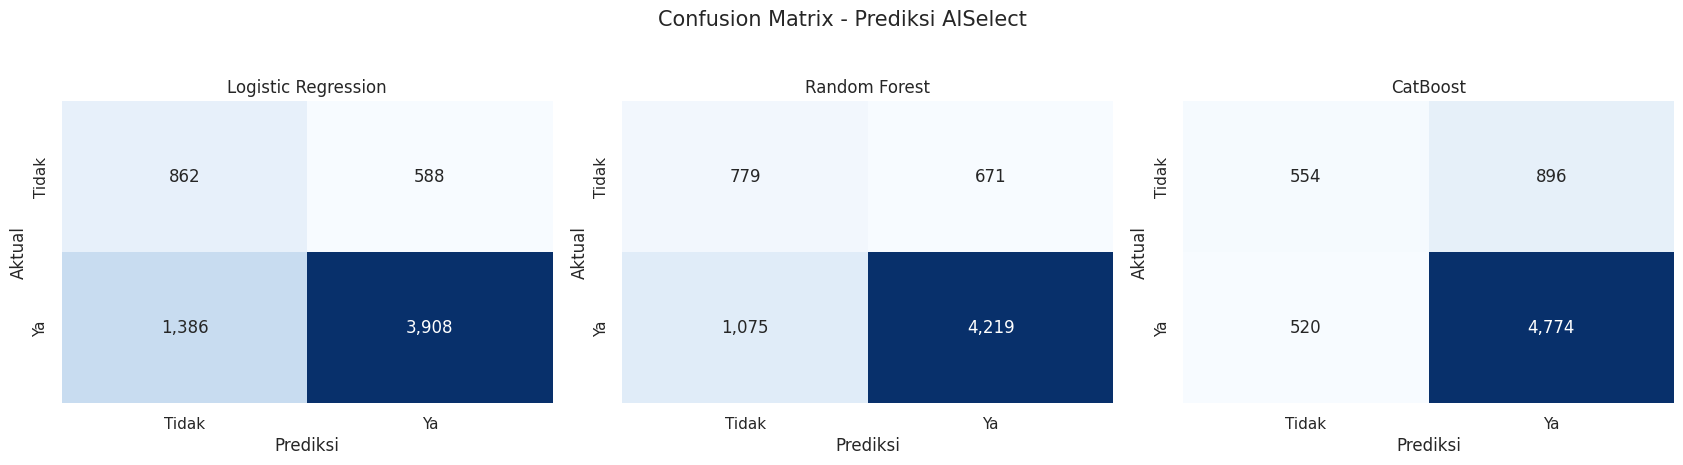

Ringkasan F1-score:


,Model,F1 Tidak,F1 Ya,F1 Macro
2,CatBoost,0.4390,0.8709,0.6549
1,Random Forest,0.4715,0.8286,0.6501
0,Logistic Regression,0.4662,0.7984,0.6323


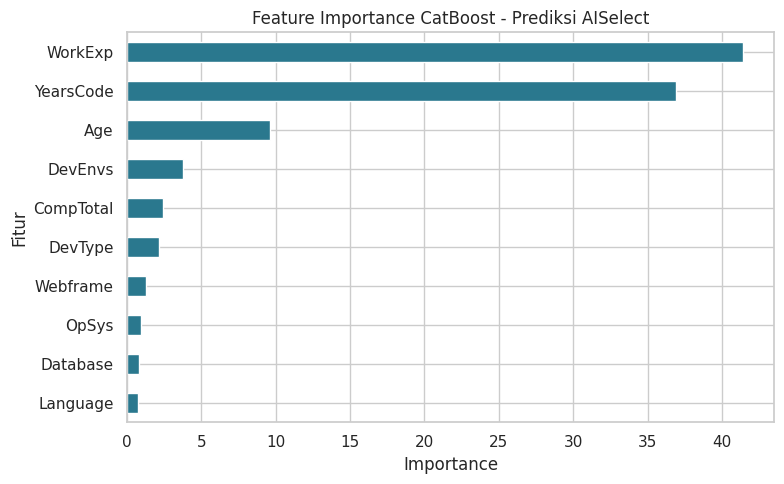

Training awal: 26,976 | setelah SMOTENC: 42,350 | testing: 6,744


In [9]:
result_ai_select = train_and_evaluate(X, Y_1, 'Prediksi AISelect')

## 6. Skenario B: Adopsi AI Agent

Bandingkan F1-score skenario ini dengan Skenario A dan amati apakah framework, bahasa, atau database menjadi fitur dominan pada feature importance.

Melatih Logistic Regression...
Melatih Random Forest...
Melatih CatBoost...

Prediksi AIAgents

--- Logistic Regression ---
              precision    recall  f1-score   support

       Tidak     0.7770    0.6047    0.6801      4409
          Ya     0.4098    0.6127    0.4911      1975

    accuracy                         0.6071      6384
   macro avg     0.5934    0.6087    0.5856      6384
weighted avg     0.6634    0.6071    0.6216      6384


--- Random Forest ---
              precision    recall  f1-score   support

       Tidak     0.7646    0.6761    0.7176      4409
          Ya     0.4254    0.5352    0.4740      1975

    accuracy                         0.6325      6384
   macro avg     0.5950    0.6057    0.5958      6384
weighted avg     0.6596    0.6325    0.6423      6384


--- CatBoost ---
              precision    recall  f1-score   support

       Tidak     0.7376    0.8340    0.7828      4409
          Ya     0.4768    0.3377    0.3954      1975

    accuracy     

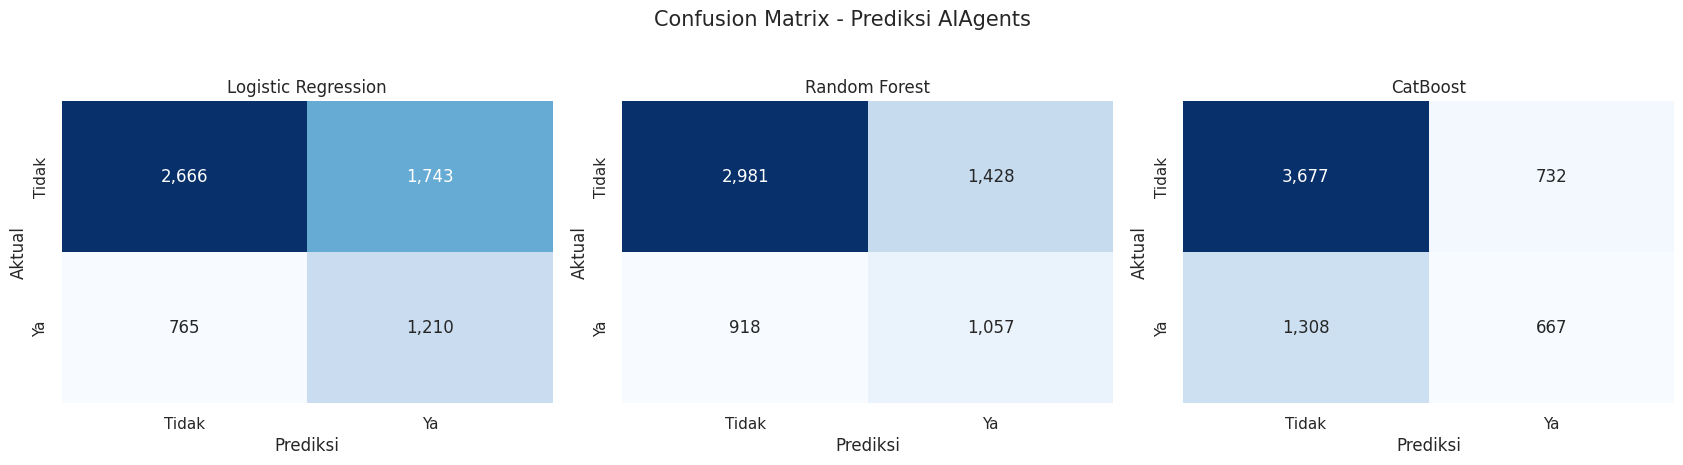

Ringkasan F1-score:


,Model,F1 Tidak,F1 Ya,F1 Macro
1,Random Forest,0.7176,0.4740,0.5958
2,CatBoost,0.7828,0.3954,0.5891
0,Logistic Regression,0.6801,0.4911,0.5856


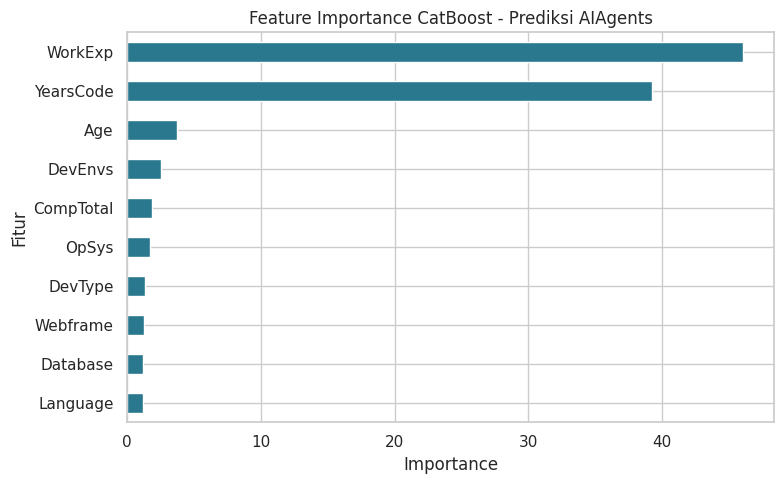

Training awal: 25,535 | setelah SMOTENC: 35,270 | testing: 6,384


In [10]:
result_ai_agents = train_and_evaluate(X, Y_2, 'Prediksi AIAgents')

## 7. Perbandingan kedua skenario

In [11]:
comparison = pd.concat(
    [
        result_ai_select['summary'].assign(Skenario='AISelect'),
        result_ai_agents['summary'].assign(Skenario='AIAgents'),
    ],
    ignore_index=True,
).sort_values(['Skenario', 'F1 Macro'], ascending=[True, False])

display(comparison[['Skenario', 'Model', 'F1 Tidak', 'F1 Ya', 'F1 Macro']].style.format({
    'F1 Tidak': '{:.4f}', 'F1 Ya': '{:.4f}', 'F1 Macro': '{:.4f}'
}))

,Skenario,Model,F1 Tidak,F1 Ya,F1 Macro
3,AIAgents,Random Forest,0.7176,0.4740,0.5958
4,AIAgents,CatBoost,0.7828,0.3954,0.5891
5,AIAgents,Logistic Regression,0.6801,0.4911,0.5856
0,AISelect,CatBoost,0.4390,0.8709,0.6549
1,AISelect,Random Forest,0.4715,0.8286,0.6501
2,AISelect,Logistic Regression,0.4662,0.7984,0.6323
